# Brain Tumor Segmentation from Multimodal MRI

This notebook runs and compares three classical models for binary whole-tumor segmentation on the BraTS 2020 dataset:

1. **Baseline GMM:** four MRI modalities with global GMM weights.
2. **Spatial GMM:** the baseline features with location-dependent healthy-component weights.
3. **Spatial GMM + NDI:** the spatial model with four additional symmetry features.

All models use the same fixed central slice and the same contour-based post-processing pipeline so that their test results are directly comparable.

## Experimental design

Each BraTS case contains T1, T1ce, T2 and FLAIR MRI modalities and a three-channel tumor annotation. The three annotation channels are combined into one binary whole-tumor ground truth.

To reduce computation, slice 80 is selected from every volume using the same rule for training, validation and testing. The patient-level split is:

- Training: volumes 1-250
- Validation: volumes 251-300
- Test: volumes 301-369

The test set is used only for the final comparison. Dice and IoU are calculated separately for every test volume.

## Imports and configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import pearsonr

from config import (
    GMM_REGULAR_COMPONENTS,
    GMM_SYMMETRIC_COMPONENTS,
    LAMBDA,
    MAX_TRAINING_VOLUME,
    MAX_VALIDATION_VOLUME,
    PROJECT_ROOT,
    RANDOM_SEED,
    SLICE_NUM,
    TOTAL_VOLUMES,
)
from evaluation.evaluate_single_slice import eval_vol
from evaluation.evaluate_test_set import eval_dataset
from statistical_models.train_healthy import fit_and_save_healthy_gmm
from statistical_models.train_local_weights import compute_and_save_local_weights
from statistical_models.train_tumor import fit_and_save_tumor_gmm
from utilities.utils import load_and_normalize_slice

np.random.seed(RANDOM_SEED)
%matplotlib inline

dataset director:  /truenas/home/ratzabiy/MRI_2026_datasets/Brats/BraTS2020_training_data/content/data


In [2]:
MODELS_DIR = Path(PROJECT_ROOT) / "saved_parameters" / "statistical_models"
FIGURES_DIR = Path(PROJECT_ROOT) / "output" / "required_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_SPECS = {
    "Baseline GMM": {"model_name": "baseline_gmm", "symmetric": False, "lambda_val": 0.0},
    "Spatial GMM": {"model_name": "spatial_gmm", "symmetric": False, "lambda_val": LAMBDA},
    "Spatial GMM + NDI": {"model_name": "spatial_gmm_ndi", "symmetric": True, "lambda_val": LAMBDA},
}
RESULTS = {}

experiment_config = pd.DataFrame({
    "Setting": ["Central slice", "Training volumes", "Validation volumes", "Test volumes", "Regular GMM components", "NDI GMM components", "Spatial lambda", "Random seed"],
    "Value": [SLICE_NUM, f"1-{MAX_TRAINING_VOLUME}", f"{MAX_TRAINING_VOLUME + 1}-{MAX_VALIDATION_VOLUME}", f"{MAX_VALIDATION_VOLUME + 1}-{TOTAL_VOLUMES}", GMM_REGULAR_COMPONENTS, GMM_SYMMETRIC_COMPONENTS, LAMBDA, RANDOM_SEED],
})
display(experiment_config)

,Setting,Value
0,Central slice,80
1,Training volumes,1-250
2,Validation volumes,251-300
3,Test volumes,301-369
4,Regular GMM components,12
5,NDI GMM components,24
6,Spatial lambda,0.23
7,Random seed,42


## Data and MRI-specific preprocessing

Each modality is normalized with the corresponding volume-level mean and standard deviation. A brain mask is created from nonzero MRI pixels and eroded slightly to reduce boundary artifacts. The following visualization uses a training case, so no test annotation is inspected during model development.

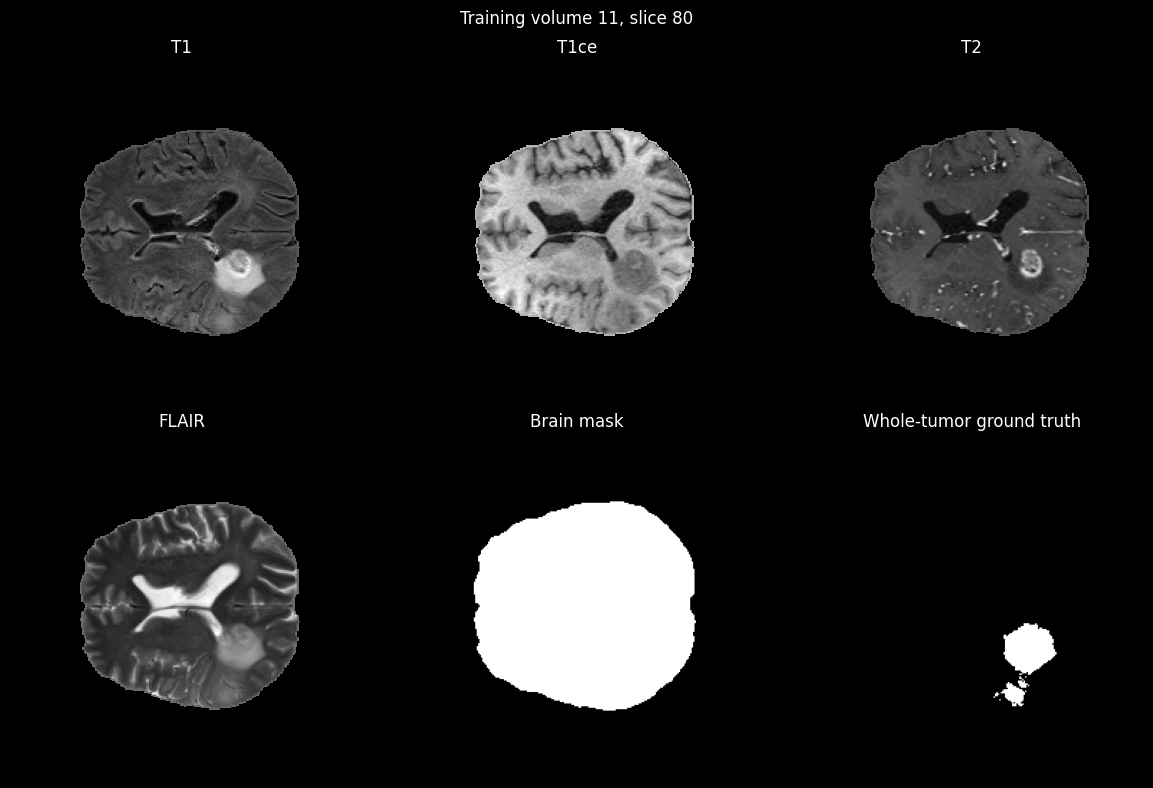

In [3]:
sample_volume = 11
sample_image, sample_brain_mask, sample_gt = load_and_normalize_slice(sample_volume, SLICE_NUM)
sample_gt_binary = np.any(sample_gt > 0, axis=-1)
modality_names = ["T1", "T1ce", "T2", "FLAIR"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for channel, name in enumerate(modality_names):
    axes.flat[channel].imshow(np.where(sample_brain_mask, sample_image[:, :, channel], np.nan), cmap="gray")
    axes.flat[channel].set_title(name)
axes.flat[4].imshow(sample_brain_mask, cmap="gray")
axes.flat[4].set_title("Brain mask")
axes.flat[5].imshow(sample_gt_binary, cmap="gray")
axes.flat[5].set_title("Whole-tumor ground truth")
for ax in axes.flat:
    ax.axis("off")
fig.suptitle(f"Training volume {sample_volume}, slice {SLICE_NUM}")
plt.tight_layout()
plt.show()

## Shared segmentation pipeline

All three models first estimate a healthy likelihood and three tumor-tissue likelihoods. Bayes normalization produces one healthy posterior and three tumor posteriors. The three tumor posteriors are merged for binary whole-tumor segmentation.

The shared post-processing stages are:

1. Calculate posterior entropy.
2. Detect gradients in the merged tumor posterior using a Sobel filter.
3. Convert closed contours into candidate regions.
4. Classify candidate regions using entropy-weighted tumor probability.
5. Expand accepted tumor seeds into adjacent uncertain pixels.

Keeping these stages identical isolates the effect of the statistical model.

# Model 1: Baseline GMM

The baseline uses the four normalized MRI intensities and global healthy GMM weights. Setting `lambda_val=0` ensures that no location-dependent weights are used. Each of the three tumor tissues is modeled by an independent four-component GMM.

In [4]:
regular_healthy_path = MODELS_DIR / "healthy_gmm.npz"
regular_tumor_path = MODELS_DIR / "tumor_gmm.npz"

if not regular_healthy_path.exists():
    fit_and_save_healthy_gmm(symmetric=False)
if not regular_tumor_path.exists():
    fit_and_save_tumor_gmm(symmetric=False)

print("Baseline statistical parameters are ready.")

Fitting class 0: 55,097 pixels, prior=0.012802
  converged=True, iterations=43
Fitting class 1: 247,670 pixels, prior=0.057548
  converged=True, iterations=28
Fitting class 2: 92,685 pixels, prior=0.021536
  converged=True, iterations=32
Tumor GMM parameters saved to '/truenas/home/ratzabiy/Brain_Tumor_Segmentation/saved_parameters/statistical_models/tumor_gmm.npz'
Baseline statistical parameters are ready.


In [5]:
baseline_spec = MODEL_SPECS["Baseline GMM"]
RESULTS["Baseline GMM"] = eval_dataset(**baseline_spec)

Evaluating 69 test volumes: baseline_gmm (symmetric=False, lambda=0.00)
Dice: 0.6817 +/- 0.3590
IoU:  0.6110 +/- 0.3499
Missed tumors: 12/60



# Model 2: Spatial GMM

The spatial model uses the same four MRI features and the same fitted distributions as the baseline. Its improvement is a coordinate-dependent healthy-component weight map learned from the training set.

The local and global weights are interpolated as

$$\tilde{\pi}_k(x,y)=(1-\lambda)\pi_k+\lambda\pi_k(x,y).$$

The value of $\lambda$ is selected using the validation set and is never optimized on the test set.

In [6]:
regular_local_weights_path = MODELS_DIR / "local_weights.npz"
if not regular_local_weights_path.exists():
    compute_and_save_local_weights(symmetric=False)
print("Regular spatial weights are ready.")

Regular spatial weights are ready.


In [7]:
spatial_spec = MODEL_SPECS["Spatial GMM"]
RESULTS["Spatial GMM"] = eval_dataset(**spatial_spec)

Evaluating 69 test volumes: spatial_gmm (symmetric=False, lambda=0.23)
Dice: 0.7148 +/- 0.3307
IoU:  0.6394 +/- 0.3286
Missed tumors: 9/60



# Model 3: Spatial GMM + NDI

The final model keeps the spatial weights and adds four Normalized Difference Index features. For each modality, NDI compares a voxel with its mirrored location:

$$NDI_m(x,y)=\frac{I_m(x,y)-I_m(\mathrm{mirror}(x,y))}{I_m(x,y)+I_m(\mathrm{mirror}(x,y))}.$$

The resulting feature vector contains the four normalized MRI intensities and four NDI values. This introduces anatomical symmetry information that may help identify unilateral abnormalities.

In [8]:
symmetric_healthy_path = MODELS_DIR / "healthy_gmm_symmetric.npz"
symmetric_tumor_path = MODELS_DIR / "tumor_gmm_symmetric.npz"
symmetric_local_weights_path = MODELS_DIR / "local_weights_symmetric.npz"

if not symmetric_healthy_path.exists():
    fit_and_save_healthy_gmm(symmetric=True)
if not symmetric_tumor_path.exists():
    fit_and_save_tumor_gmm(symmetric=True)
if not symmetric_local_weights_path.exists():
    compute_and_save_local_weights(symmetric=True)

print("NDI statistical parameters and spatial weights are ready.")

Fitting class 0: 55,097 pixels, prior=0.012802
  converged=True, iterations=51
Fitting class 1: 247,670 pixels, prior=0.057548
  converged=True, iterations=21
Fitting class 2: 92,685 pixels, prior=0.021536
  converged=True, iterations=20
Tumor GMM parameters saved to '/truenas/home/ratzabiy/Brain_Tumor_Segmentation/saved_parameters/statistical_models/tumor_gmm_symmetric.npz'
NDI statistical parameters and spatial weights are ready.


In [9]:
ndi_spec = MODEL_SPECS["Spatial GMM + NDI"]
RESULTS["Spatial GMM + NDI"] = eval_dataset(**ndi_spec)

Evaluating 69 test volumes: spatial_gmm_ndi (symmetric=True, lambda=0.23)
Dice: 0.7423 +/- 0.3094
IoU:  0.6638 +/- 0.3034
Missed tumors: 6/60



# Final test-set evaluation

The project instructions require per-test-sample Dice and IoU, their mean and standard deviation, box plots, paired scatter plots with Pearson correlation, and representative qualitative examples. Because this project evaluates three models, all three are included in every comparison.

If both the prediction and ground truth are empty, Dice and IoU are defined as 1 because the tumor-free slice was classified correctly.

## Quantitative results table

In [10]:
results_table = pd.DataFrame([
    {
        "Model": model_name,
        "Dice mean": result["mean_dice"],
        "Dice std": result["std_dice"],
        "IoU mean": result["mean_iou"],
        "IoU std": result["std_iou"],
        "Missed tumors": f"{result['missed_tumors_count']}/{result['gt_tumors_count']}",
    }
    for model_name, result in RESULTS.items()
])
results_table.to_csv(Path(PROJECT_ROOT) / "output" / "test_results.csv", index=False)
display(results_table.round(4))

,Model,Dice mean,Dice std,IoU mean,IoU std,Missed tumors
0,Baseline GMM,0.6817,0.3590,0.6110,0.3499,12/60
1,Spatial GMM,0.7148,0.3307,0.6394,0.3286,9/60
2,Spatial GMM + NDI,0.7423,0.3094,0.6638,0.3034,6/60


## Dice and IoU box plots

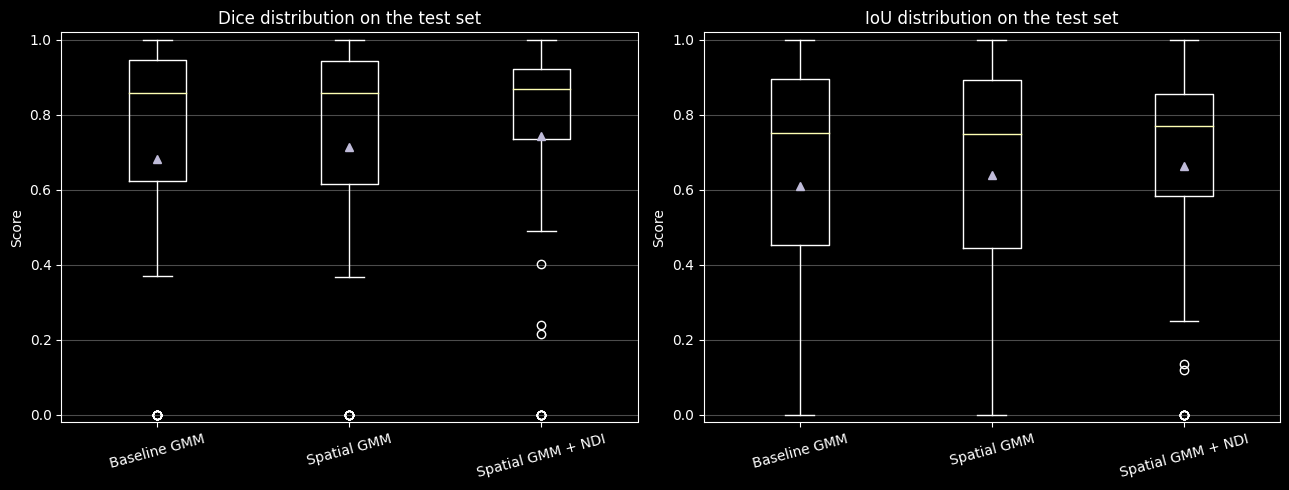

In [11]:
model_labels = list(RESULTS)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric_key, title in zip(
    axes,
    ["dice_per_volume", "iou_per_volume"],
    ["Dice distribution on the test set", "IoU distribution on the test set"],
):
    ax.boxplot([RESULTS[name][metric_key] for name in model_labels], labels=model_labels, showmeans=True)
    ax.set_title(title)
    ax.set_ylabel("Score")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dice_iou_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

## Paired performance scatter plots

Every point represents the same test volume under the baseline and one improved model. The dashed diagonal indicates equal performance. Pearson $r$ measures whether the models succeed and fail on similar patients; it does not by itself measure improvement.

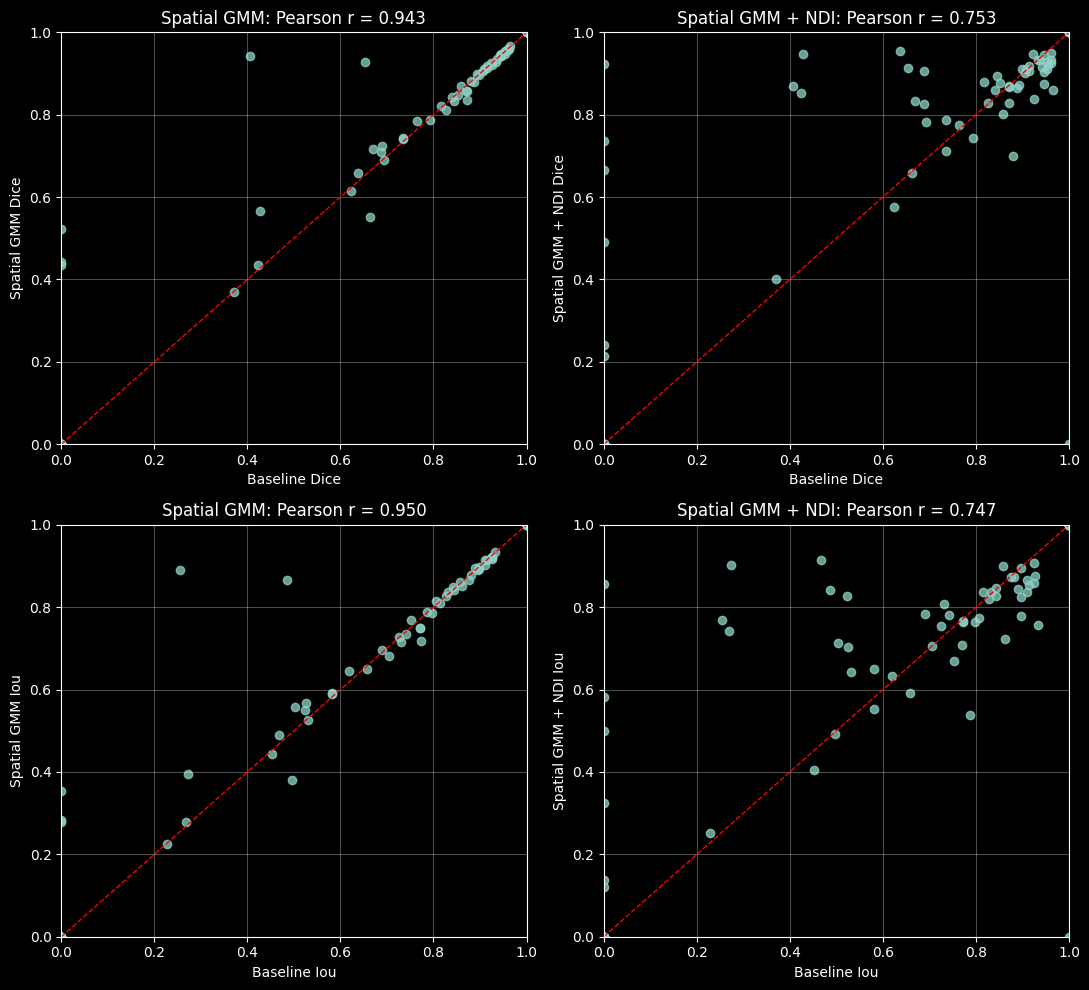

In [12]:
baseline = RESULTS["Baseline GMM"]
comparison_models = ["Spatial GMM", "Spatial GMM + NDI"]
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for row, metric in enumerate(["dice", "iou"]):
    key = f"{metric}_per_volume"
    for column, model_name in enumerate(comparison_models):
        x = baseline[key]
        y = RESULTS[model_name][key]
        r, _ = pearsonr(x, y)
        ax = axes[row, column]
        ax.scatter(x, y, alpha=0.75)
        ax.plot([0, 1], [0, 1], "--", color="red", linewidth=1)
        ax.set(xlim=(0, 1), ylim=(0, 1), xlabel=f"Baseline {metric.title()}", ylabel=f"{model_name} {metric.title()}")
        ax.set_title(f"{model_name}: Pearson r = {r:.3f}")
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "paired_metric_scatterplots.png", dpi=300, bbox_inches="tight")
plt.show()

## Required qualitative examples

The required categories are selected using Dice while comparing the baseline with the final Spatial GMM + NDI model. The intermediate Spatial GMM output is also displayed. The selected cases are:

- Highest minimum score: both models performed well.
- Lowest maximum score: both models performed poorly.
- Largest positive baseline-minus-final difference: baseline performed better.
- Largest positive final-minus-baseline difference: final model performed better.

If one difference category does not occur, the notebook states this rather than fabricating an example.

In [13]:
def first_unused(order, used):
    return next((int(index) for index in order if int(index) not in used), None)

base_dice = RESULTS["Baseline GMM"]["dice_per_volume"]
final_dice = RESULTS["Spatial GMM + NDI"]["dice_per_volume"]
used_indices = set()
case_indices = {}

case_orders = {
    "Both performed well": np.argsort(-np.minimum(base_dice, final_dice)),
    "Both performed poorly": np.argsort(np.maximum(base_dice, final_dice)),
}
for label, order in case_orders.items():
    selected = first_unused(order, used_indices)
    case_indices[label] = selected
    used_indices.add(selected)

baseline_difference = base_dice - final_dice
advanced_difference = final_dice - base_dice
for label, difference in [
    ("Baseline performed better", baseline_difference),
    ("Spatial GMM + NDI performed better", advanced_difference),
]:
    if np.max(difference) <= 0:
        case_indices[label] = None
        print(f"No test case where {label.lower()}.")
    else:
        selected = first_unused(np.argsort(-difference), used_indices)
        case_indices[label] = selected
        used_indices.add(selected)

selected_cases = {
    label: int(baseline["volume_numbers"][index])
    for label, index in case_indices.items()
    if index is not None
}
display(pd.DataFrame(selected_cases.items(), columns=["Category", "Volume"]))

,Category,Volume
0,Both performed well,304
1,Both performed poorly,302
2,Baseline performed better,332
3,Spatial GMM + NDI performed better,368


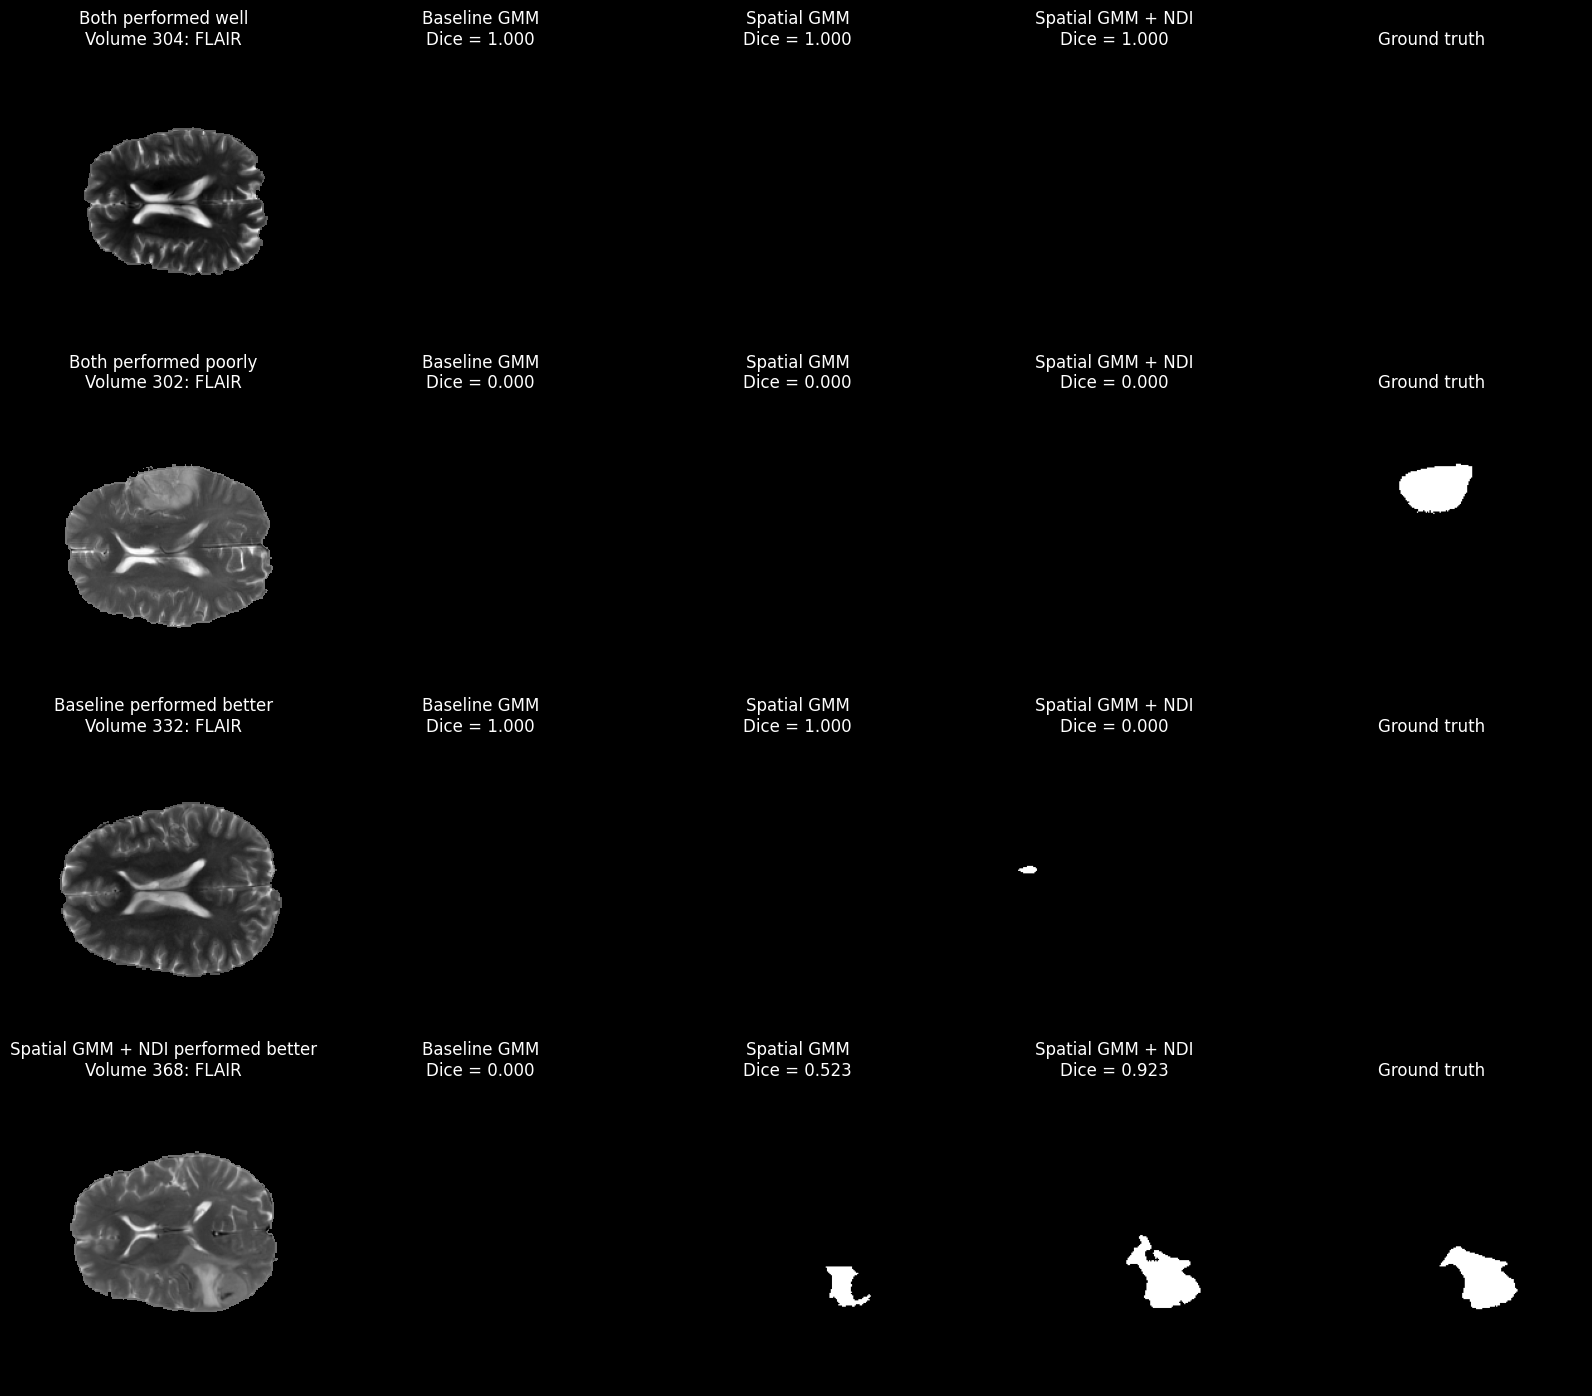

In [14]:
fig, axes = plt.subplots(len(selected_cases), 5, figsize=(16, 3.5 * len(selected_cases)), squeeze=False)

for row, (category, volume) in enumerate(selected_cases.items()):
    predictions = {
        label: eval_vol(volume, return_details=True, **spec)
        for label, spec in MODEL_SPECS.items()
    }
    reference = predictions["Baseline GMM"]
    axes[row, 0].imshow(np.where(reference["brain_mask"], reference["image"][:, :, 3], np.nan), cmap="gray")
    axes[row, 0].set_title(f"{category}\nVolume {volume}: FLAIR")

    for column, label in enumerate(MODEL_SPECS, start=1):
        details = predictions[label]
        axes[row, column].imshow(details["prediction"], cmap="gray")
        axes[row, column].set_title(f"{label}\nDice = {details['dice']:.3f}")

    axes[row, 4].imshow(reference["ground_truth"], cmap="gray")
    axes[row, 4].set_title("Ground truth")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "qualitative_examples.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary and interpretation

In [15]:
best_model = results_table.loc[results_table["Dice mean"].idxmax(), "Model"]
baseline_mean = RESULTS["Baseline GMM"]["mean_dice"]

print(f"Highest mean test Dice: {best_model}")
for model_name in ["Spatial GMM", "Spatial GMM + NDI"]:
    difference = RESULTS[model_name]["mean_dice"] - baseline_mean
    print(f"{model_name} Dice difference from baseline: {difference:+.4f}")

Highest mean test Dice: Spatial GMM + NDI
Spatial GMM Dice difference from baseline: +0.0332
Spatial GMM + NDI Dice difference from baseline: +0.0606


The final report should interpret these results in MRI terms: whether location-dependent healthy-tissue expectations reduce anatomically implausible false positives, whether NDI highlights unilateral tumor-related contrast changes, and where normal asymmetry or weak tumor contrast causes failure. The report should also discuss the central-slice limitation and the fact that the current regular and NDI models use different healthy-GMM component counts.